# Caracterización y validación de las fuentes complementarias, 2023–2025

**Caracterización de los factores que afectan la producción de oro en Colombia, 2023–2025**




In [1]:
import json
import re
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
AZUL, DORADO, TEAL, GRIS = "#1F3864", "#BF8F00", "#2E7D77", "#9E9E9E"
ANIOS = [2023, 2024, 2025]
ONZA_TROY_G = 31.1034768
TOPE_BAREQ_G_ANIO = 35 * 12


def encontrar_raiz():
    p = Path.cwd().resolve()
    for c in [p] + list(p.parents):
        if (c / "02_produccion_regalias").exists() and (c / "05_delictiva").exists():
            return c
    raise FileNotFoundError("No encuentro BDATOS-ORO con la carpeta 05_delictiva: corre antes scripts/02_descarga_complementos.py")


RAIZ = encontrar_raiz(); SAL = RAIZ / "06_panel"
print("Raíz del repositorio:", RAIZ)
CHECKS = []


def check(bloque, nombre, ok, detalle=""):
    CHECKS.append((bloque, nombre, "OK" if ok else "REVISAR", str(detalle)))
    print(f"[{'OK' if ok else 'REVISAR':7}] {nombre}" + (f" — {detalle}" if detalle != "" else ""))


def perfil(df):
    ej = {c: (df[c].dropna().iloc[0] if df[c].notna().any() else None) for c in df.columns}
    return pd.DataFrame({"tipo": df.dtypes.astype(str), "n_no_nulos": df.notna().sum(), "pct_nulos": (df.isna().mean() * 100).round(2), "n_unicos": df.nunique(), "ejemplo": pd.Series(ej)})


def resumen_num(s, nombre=None):
    s = pd.to_numeric(s, errors="coerce"); q = s.quantile([0.05, 0.25, 0.5, 0.75, 0.95])
    return pd.Series({"n": s.notna().sum(), "nulos": s.isna().sum(), "ceros": (s == 0).sum(), "media": s.mean(), "desv_est": s.std(), "cv": (s.std() / s.mean()) if s.mean() else np.nan,
                      "min": s.min(), "p5": q[0.05], "p25": q[0.25], "mediana": q[0.5], "p75": q[0.75], "p95": q[0.95], "max": s.max(), "asimetria": s.skew(), "curtosis": s.kurt()}, name=nombre or s.name)


def tabla_resumen(df, cols):
    return pd.concat([resumen_num(df[c], c) for c in cols], axis=1).T


def normaliza(t):
    if pd.isna(t):
        return ""
    return re.sub(r"[^A-Z0-9]", "", unicodedata.normalize("NFKD", str(t)).encode("ascii", "ignore").decode().upper())


DEPTOS = {"05": "Antioquia", "08": "Atlántico", "11": "Bogotá, D.C.", "13": "Bolívar", "15": "Boyacá", "17": "Caldas", "18": "Caquetá", "19": "Cauca", "20": "Cesar", "23": "Córdoba",
          "25": "Cundinamarca", "27": "Chocó", "41": "Huila", "44": "La Guajira", "47": "Magdalena", "50": "Meta", "52": "Nariño", "54": "Norte de Santander", "63": "Quindío", "66": "Risaralda",
          "68": "Santander", "70": "Sucre", "73": "Tolima", "76": "Valle del Cauca", "81": "Arauca", "85": "Casanare", "86": "Putumayo", "88": "San Andrés", "91": "Amazonas", "94": "Guainía",
          "95": "Guaviare", "97": "Vaupés", "99": "Vichada"}

# Panel del notebook 01 (no se modifica; se lee para cruzar y para ampliar)
panel = pd.read_csv(SAL / "panel_municipal_2023_2025.csv", dtype={"codigo_dane": str})
pq = pd.read_csv(SAL / "panel_municipal_trimestral_2023_2025.csv", dtype={"codigo_dane": str})
UNIVERSO = sorted(panel.codigo_dane.unique())
ficha = json.load(open(RAIZ / "ficha_descarga_complementos.json", encoding="utf-8"))
print(f"Panel del notebook 01: {panel.shape[0]} filas, {len(UNIVERSO)} municipios; ficha de descarga del {ficha.get('fecha_descarga')}")

Raíz del repositorio: /Users/juandavidnietodallos/Documents/7 Semestre /Tesis /BDATOS-ORO
Panel del notebook 01: 591 filas, 197 municipios; ficha de descarga del 2026-10-06


## 1. Inventario de las fuentes nuevas

In [2]:
INVENTARIO = [
    ("05 Delictiva", "05_delictiva/homicidio_municipal_mensual_2023_2025.csv", "Policía Nacional (datos.gov.co m8fd-ahd9)", "municipio × mes", "2023–2025"),
    ("05 Delictiva", "05_delictiva/extorsion_municipal_mensual_2023_2025.csv", "Policía Nacional (datos.gov.co q2ib-t9am)", "municipio × mes", "2023–2025"),
    ("11 Población", "11_poblacion/dane_poblacion_municipal_2023_2025.csv", "DANE, proyecciones post-censo 2018 (jul-2025)", "municipio × año", "2023–2025"),
    ("12 RUCOM", "12_titulos_rucom/rucom_titulos_oro.csv", "ANM RUCOM (datos.gov.co 42ha-fhvj)", "título × municipio × mineral", "foto ene-2025"),
    ("12 RUCOM", "12_titulos_rucom/rucom_solicitudes_legalizacion_oro.csv", "ANM RUCOM (datos.gov.co 7amp-4swy)", "solicitud × municipio × mineral", "foto ene-2025"),
    ("12 RUCOM", "12_titulos_rucom/rucom_subcontratos_formalizacion_oro.csv", "ANM RUCOM (datos.gov.co xzu3-gnau)", "subcontrato × municipio × mineral", "foto ene-2025"),
    ("12 RUCOM", "12_titulos_rucom/rucom_figuras_oro_municipio.csv", "derivada de las tres anteriores", "municipio", "foto"),
    ("12 RUCOM", "12_titulos_rucom/rmn_anotaciones_titulos_2023_2025.csv", "ANM Registro Minero Nacional (datos.gov.co si2v-pbq5)", "anotación", "2023–2025"),
    ("13 Territorio", "13_territorio/mgn_area_municipal_km2.csv", "DANE MGN 2024", "municipio", "fija"),
    ("13 Territorio", "13_territorio/municipios_pdet.csv", "ART (datos.gov.co idrk-ba8y)", "municipio", "fija"),
    ("01 Precio", "01_precio/upme_precio_base_regalias_opp_mensual_2025.csv", "UPME, página de precios base", "nacional × mes", "mar–dic 2025"),
    ("06 Panel", "06_panel/complementos_municipio_anual_2023_2025.csv", "derivada (script 02)", "municipio × año", "2023–2025"),
]
filas = []
for bloque, rel, fuente, grano, ventana in INVENTARIO:
    ruta = RAIZ / rel
    if not ruta.exists():
        filas.append((bloque, rel, fuente, grano, ventana, "NO EXISTE", None, None)); continue
    df = pd.read_csv(ruta, dtype=str)
    filas.append((bloque, rel, fuente, grano, ventana, round(ruta.stat().st_size / 1024, 1), len(df), df.shape[1]))
inventario = pd.DataFrame(filas, columns=["bloque", "archivo", "fuente", "grano", "ventana", "KB", "filas", "columnas"])
check("Inventario", "Todas las fuentes nuevas están en el repositorio", (inventario.KB != "NO EXISTE").all(), f"{(inventario.KB == 'NO EXISTE').sum()} faltantes")
inventario

[OK     ] Todas las fuentes nuevas están en el repositorio — 0 faltantes


,bloque,archivo,fuente,grano,ventana,KB,filas,columnas
0,05 Delictiva,05_delictiva/homicidio_municipal_mensual_2023_2025.csv,Policía Nacional (datos.gov.co m8fd-ahd9),municipio × mes,2023–2025,398.70,11720,6
1,05 Delictiva,05_delictiva/extorsion_municipal_mensual_2023_2025.csv,Policía Nacional (datos.gov.co q2ib-t9am),municipio × mes,2023–2025,326.60,9578,6
2,11 Población,11_poblacion/dane_poblacion_municipal_2023_2025.csv,"DANE, proyecciones post-censo 2018 (jul-2025)",municipio × año,2023–2025,194.50,3369,8
3,12 RUCOM,12_titulos_rucom/rucom_titulos_oro.csv,ANM RUCOM (datos.gov.co 42ha-fhvj),título × municipio × mineral,foto ene-2025,133.70,1509,7
4,12 RUCOM,12_titulos_rucom/rucom_solicitudes_legalizacion_oro.csv,ANM RUCOM (datos.gov.co 7amp-4swy),solicitud × municipio × mineral,foto ene-2025,89.40,912,6
5,12 RUCOM,12_titulos_rucom/rucom_subcontratos_formalizacion_oro.csv,ANM RUCOM (datos.gov.co xzu3-gnau),subcontrato × municipio × mineral,foto ene-2025,20.30,201,8
6,12 RUCOM,12_titulos_rucom/rucom_figuras_oro_municipio.csv,derivada de las tres anteriores,municipio,foto,3.40,159,8
7,12 RUCOM,12_titulos_rucom/rmn_anotaciones_titulos_2023_2025.csv,ANM Registro Minero Nacional (datos.gov.co si2v-pbq5),anotación,2023–2025,"3,282.10",12988,10
8,13 Territorio,13_territorio/mgn_area_municipal_km2.csv,DANE MGN 2024,municipio,fija,33.10,1121,3
9,13 Territorio,13_territorio/municipios_pdet.csv,ART (datos.gov.co idrk-ba8y),municipio,fija,9.00,170,6


## 2. Homicidio y extorsión (Policía Nacional, municipio × mes)

Son conteos de hechos registrados por la Policía con el código DANE del municipio. Un municipio-mes ausente son cero casos, la misma regla que los operativos. Se comprueban llaves, meses completos, duplicados, y que lo descargado reproduzca el total de la fuente (la ficha del script guarda ese total).

== homicidio: (11720, 6)


,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
cod_muni,object,11720,0.00,974,05001
departamento,object,11720,0.00,33,ANTIOQUIA
municipio,object,11720,0.00,906,MEDELLIN
anio,int64,11720,0.00,3,2023
mes,int64,11720,0.00,12,1
casos,int64,11720,0.00,89,28


[OK     ] homicidio: código DANE de 5 dígitos con departamento válido
[OK     ] homicidio: sin duplicados municipio-año-mes; casos enteros no negativos
[OK     ] homicidio: los tres años traen 12 meses — {2023: 12, 2024: 12, 2025: 12}
[OK     ] homicidio: la descarga completa reproduce el total de la fuente (ficha) — 344,919 casos en la fuente
[OK     ] homicidio: un solo nombre de municipio por código
Nacional por año: {2023: 13555, 2024: 13497, 2025: 14038} | municipios con algún caso: 974
== extorsion: (9578, 6)


,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
cod_muni,object,9578,0.00,974,05001
departamento,object,9578,0.00,33,ANTIOQUIA
municipio,object,9578,0.00,910,MEDELLIN
anio,int64,9578,0.00,3,2023
mes,int64,9578,0.00,12,1
casos,int64,9578,0.00,123,83


[OK     ] extorsion: código DANE de 5 dígitos con departamento válido
[OK     ] extorsion: sin duplicados municipio-año-mes; casos enteros no negativos
[OK     ] extorsion: los tres años traen 12 meses — {2023: 12, 2024: 12, 2025: 12}
[OK     ] extorsion: la descarga completa reproduce el total de la fuente (ficha) — 131,206 casos en la fuente
[OK     ] extorsion: un solo nombre de municipio por código
Nacional por año: {2023: 11078, 2024: 13802, 2025: 13417} | municipios con algún caso: 974
homicidio: 190 de 197 municipios del universo tienen algún caso en 2023–2025; municipio-años con casos: 525 de 591
extorsion: 187 de 197 municipios del universo tienen algún caso en 2023–2025; municipio-años con casos: 500 de 591


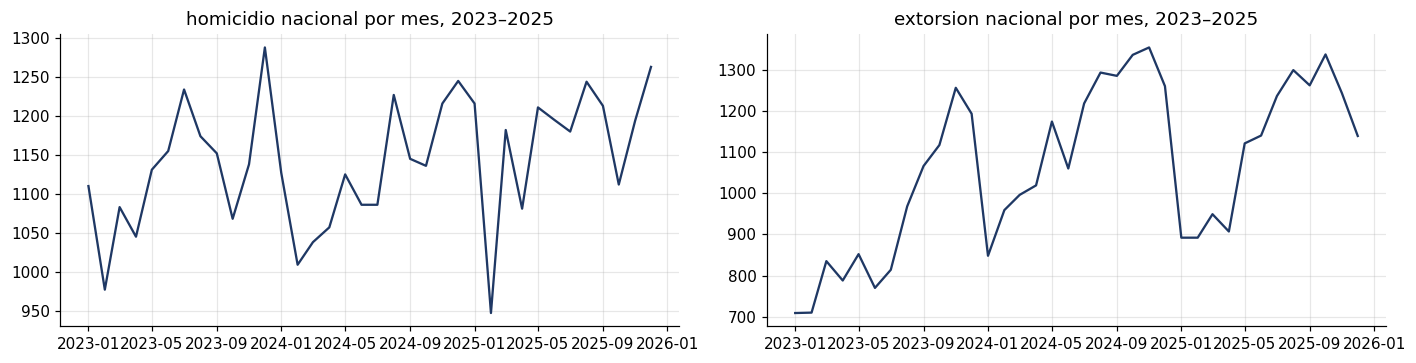

In [3]:
delic = {}
for nombre in ["homicidio", "extorsion"]:
    d = pd.read_csv(RAIZ / f"05_delictiva/{nombre}_municipal_mensual_2023_2025.csv", dtype={"cod_muni": str})
    print(f"== {nombre}: {d.shape}"); display(perfil(d))
    check("05 Delictiva", f"{nombre}: código DANE de 5 dígitos con departamento válido", (d.cod_muni.str.len() == 5).all() and d.cod_muni.str[:2].isin(DEPTOS).all())
    check("05 Delictiva", f"{nombre}: sin duplicados municipio-año-mes; casos enteros no negativos", not d.duplicated(["cod_muni", "anio", "mes"]).any() and (d.casos >= 0).all() and (d.casos == d.casos.round()).all())
    check("05 Delictiva", f"{nombre}: los tres años traen 12 meses", all(d.loc[d.anio == a, "mes"].nunique() == 12 for a in ANIOS), {a: int(d.loc[d.anio == a, 'mes'].nunique()) for a in ANIOS})
    check("05 Delictiva", f"{nombre}: la descarga completa reproduce el total de la fuente (ficha)", ficha[nombre]["coincide"], f"{ficha[nombre]['total_fuente_sum_cantidad']:,} casos en la fuente")
    check("05 Delictiva", f"{nombre}: un solo nombre de municipio por código", (d.groupby("cod_muni").municipio.nunique() == 1).all())
    nac = d.groupby("anio").casos.sum(); print("Nacional por año:", nac.to_dict(), "| municipios con algún caso:", d.cod_muni.nunique())
    delic[nombre] = d
# Cobertura del universo del panel
for nombre, d in delic.items():
    en_uni = d[d.cod_muni.isin(UNIVERSO)]
    print(f"{nombre}: {en_uni.cod_muni.nunique()} de {len(UNIVERSO)} municipios del universo tienen algún caso en 2023–2025; municipio-años con casos: {en_uni.groupby(['cod_muni','anio']).size().shape[0]} de {len(UNIVERSO) * 3}")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
for a, (nombre, d) in zip(ax, delic.items()):
    m = d.groupby(["anio", "mes"]).casos.sum().reset_index(); m["fecha"] = pd.to_datetime(dict(year=m.anio, month=m.mes, day=1))
    a.plot(m.fecha, m.casos, color=AZUL); a.set_title(f"{nombre} nacional por mes, 2023–2025")
plt.tight_layout(); plt.show()

## 3. Población (DANE) y tasas

La población es el denominador de homicidio, extorsión e inscritos. Se verifica que cabecera más rural sea el total, que los tres años estén completos y que todos los municipios del panel tengan población.

In [4]:
pob = pd.read_csv(RAIZ / "11_poblacion/dane_poblacion_municipal_2023_2025.csv", dtype={"cod_muni": str})
display(perfil(pob))
check("11 Población", "Código de 5 dígitos, sin duplicados municipio-año, tres años por municipio", (pob.cod_muni.str.len() == 5).all() and not pob.duplicated(["cod_muni", "anio"]).any() and (pob.groupby("cod_muni").anio.nunique() == 3).all())
check("11 Población", "Cabecera + rural = total en todas las filas", ((pob.poblacion_cabecera + pob.poblacion_rural - pob.poblacion_total).abs() <= 1).all())
check("11 Población", "Todos los municipios del panel tienen población en los tres años", set(UNIVERSO) <= set(pob.cod_muni), f"faltan: {sorted(set(UNIVERSO) - set(pob.cod_muni))}")
print("Población nacional por año:", pob.groupby("anio").poblacion_total.sum().astype(int).to_dict())
pu = pob[pob.cod_muni.isin(UNIVERSO)]
display(tabla_resumen(pu, ["poblacion_total", "pct_rural"]))
# Inscritos RUCOM frente a población: el padrón de Caucasia frente a sus habitantes
rb = panel.drop_duplicates("codigo_dane")[["codigo_dane", "municipio", "n_barequeros"]].merge(pob[pob.anio == 2024][["cod_muni", "poblacion_total"]], left_on="codigo_dane", right_on="cod_muni")
rb["inscritos_por_100_hab"] = rb.n_barequeros / rb.poblacion_total * 100
print("Municipios con más inscritos por cada 100 habitantes (2024):"); display(rb.nlargest(8, "inscritos_por_100_hab")[["codigo_dane", "municipio", "n_barequeros", "poblacion_total", "inscritos_por_100_hab"]])

,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
cod_muni,object,3369,0.00,1123,05001
departamento,object,3369,0.00,33,Antioquia
municipio,object,3369,0.00,1040,Medellín
anio,int64,3369,0.00,3,2023
poblacion_total,float64,3369,0.00,3221,"2,518,480.00"
poblacion_cabecera,float64,3369,0.00,2977,"2,469,958.00"
poblacion_rural,float64,3369,0.00,3086,"48,522.00"
pct_rural,float64,3365,0.12,2718,1.93


[OK     ] Código de 5 dígitos, sin duplicados municipio-año, tres años por municipio
[OK     ] Cabecera + rural = total en todas las filas
[OK     ] Todos los municipios del panel tienen población en los tres años — faltan: []
Población nacional por año: {2023: 52117067, 2024: 52613753, 2025: 53057212}


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
poblacion_total,591.00,0.00,1.00,"54,743.47","194,120.67",3.55,0.00,"5,156.50","11,095.50","19,624.00","37,926.50","144,430.00","2,528,343.00",10.81,132.18
pct_rural,590.00,1.00,0.00,54.63,23.35,0.43,1.92,12.37,38.51,55.86,73.04,91.21,100.00,-0.26,-0.73


Municipios con más inscritos por cada 100 habitantes (2024):


,codigo_dane,municipio,n_barequeros,poblacion_total,inscritos_por_100_hab
138,27810,Union Panamericana,"9,386.00","7,202.00",130.32
124,27413,Lloro,"8,077.00","10,316.00",78.30
17,05154,Caucasia,"29,209.00","93,572.00",31.22
113,23682,San Jose de Ure,"4,716.00","15,244.00",30.94
127,27450,Medio San Juan,"2,955.00","11,112.00",26.59
119,27160,Certegui,"1,519.00","5,986.00",25.38
118,27135,El Canton del San Pablo,"1,623.00","6,486.00",25.02
116,27050,Atrato,609.00,"6,409.00",9.50


## 4. Figuras legales de oro autorizadas en el RUCOM (ANM) y anotaciones del Registro Minero Nacional

El RUCOM lista los explotadores autorizados para vender: títulos, solicitudes de legalización y subcontratos de formalización. Son las mismas categorías con que SIMCI desagrega la declaración, así que la validación cruzada natural es contra el panel: los municipios que declaran gramos por títulos deberían tener títulos autorizados, y al revés. Las anotaciones del Registro Minero Nacional dicen si esas figuras tuvieron movimiento en 2023–2025.

In [5]:
tit = pd.read_csv(RAIZ / "12_titulos_rucom/rucom_titulos_oro.csv", dtype=str)
sol = pd.read_csv(RAIZ / "12_titulos_rucom/rucom_solicitudes_legalizacion_oro.csv", dtype=str)
sub = pd.read_csv(RAIZ / "12_titulos_rucom/rucom_subcontratos_formalizacion_oro.csv", dtype=str)
fig_m = pd.read_csv(RAIZ / "12_titulos_rucom/rucom_figuras_oro_municipio.csv", dtype={"codigo_dane": str})
an = pd.read_csv(RAIZ / "12_titulos_rucom/rmn_anotaciones_titulos_2023_2025.csv", dtype=str)
for nombre, d in [("títulos", tit), ("solicitudes", sol), ("subcontratos", sub)]:
    print(f"== {nombre}: {len(d)} filas, {d.codigo_expediente.nunique()} expedientes, {d.codigo_dane.nunique()} municipios; minerales: {d.mineral.value_counts().to_dict()}")
    check("12 RUCOM", f"{nombre}: código DANE de 5 dígitos con departamento válido", (d.codigo_dane.str.len() == 5).all() and d.codigo_dane.str[:2].isin(DEPTOS).all())
    if d.duplicated().any():
        print(f"     {d.duplicated().sum()} filas idénticas repetidas en la fuente (no afectan: los conteos usan expedientes únicos)")
print("\nUn mismo expediente puede cubrir varios municipios (una fila por municipio y mineral):")
display(tit.groupby("codigo_expediente").codigo_dane.nunique().value_counts().sort_index().rename("expedientes").to_frame().T)
display(perfil(fig_m))
check("12 RUCOM", "Tabla por municipio: una fila por municipio, conteos enteros no negativos", not fig_m.codigo_dane.duplicated().any() and (fig_m.drop(columns="codigo_dane") >= 0).all().all())

# Anotaciones en la ventana
an["fecha"] = pd.to_datetime(an.fecha, errors="coerce"); an["anio"] = an.fecha.dt.year
print("\nAnotaciones RMN en la ventana:", len(an), "| por año:", an.anio.value_counts().sort_index().to_dict(), "| expedientes:", an.codigo_expediente.nunique())
print("Tipos de anotación más frecuentes:"); display(an.tipo_de_anotacion.value_counts().head(8))
con_an = tit.codigo_expediente.isin(an.codigo_expediente)
check("12 RUCOM", "Los títulos de oro del RUCOM tienen anotación registral en 2023–2025 (≥ 95 %)", con_an.groupby(tit.codigo_expediente).any().mean() >= 0.95, f"{con_an.groupby(tit.codigo_expediente).any().mean()*100:.1f} % de los expedientes")

# Validación cruzada contra el panel (gramos declarados por figura, 2023–2025)
decl = panel.groupby("codigo_dane")[["g_titulos", "g_barequeros", "g_otros", "gramos_anm"]].sum().reset_index()
x = decl.merge(fig_m, on="codigo_dane", how="outer").fillna(0)
x_uni = x[x.codigo_dane.isin(UNIVERSO)]
a = ((x_uni.g_titulos > 0) & (x_uni.n_titulos_oro > 0)).sum(); b = (x_uni.g_titulos > 0).sum(); c = ((x_uni.g_titulos == 0) & (x_uni.n_titulos_oro > 0)).sum()
print(f"\nMunicipios del universo que declaran gramos por títulos: {b}; de ellos con al menos un título de oro autorizado en el RUCOM: {a} ({a/b*100:.0f} %)")
print(f"Municipios con título autorizado y sin gramos por títulos en 2023–2025: {c}")
check("12 RUCOM", "Al menos el 70 % de los municipios que declaran por títulos tienen un título de oro autorizado en el RUCOM", a / b >= 0.70, f"{a/b*100:.0f} %")
fuera = fig_m[~fig_m.codigo_dane.isin(UNIVERSO)]
print(f"Municipios con alguna figura de oro autorizada fuera del universo del panel: {len(fuera)} (no declaran ni tienen huella 2023)")
display(tabla_resumen(x_uni, ["n_titulos_oro", "n_solicitudes_oro", "n_subcontratos_oro", "n_titulos_oro_con_anotacion_2023_2025"]))

== títulos: 1509 filas, 268 expedientes, 124 municipios; minerales: {'MINERALES DE ORO Y SUS CONCENTRADOS': 569, 'ORO': 549, 'ORO ALUVION': 266, 'MINERALES DE ORO Y PLATINO, Y SUS CONCENTRADOS': 71, 'ORO VETA': 52, 'ORO FILON': 2}
[OK     ] títulos: código DANE de 5 dígitos con departamento válido
== solicitudes: 912 filas, 112 expedientes, 70 municipios; minerales: {'MINERALES DE ORO Y SUS CONCENTRADOS': 806, 'MINERALES DE ORO Y PLATINO, Y SUS CONCENTRADOS': 105, 'ORO': 1}
[OK     ] solicitudes: código DANE de 5 dígitos con departamento válido
     619 filas idénticas repetidas en la fuente (no afectan: los conteos usan expedientes únicos)
== subcontratos: 201 filas, 174 expedientes, 45 municipios; minerales: {'MINERALES DE ORO Y SUS CONCENTRADOS': 95, 'ORO': 65, 'MINERALES DE ORO Y PLATINO, Y SUS CONCENTRADOS': 41}
[OK     ] subcontratos: código DANE de 5 dígitos con departamento válido

Un mismo expediente puede cubrir varios municipios (una fila por municipio y mineral):


codigo_dane,1,2,3,4,7
expedientes,204,50,12,1,1


,tipo,n_no_nulos,pct_nulos,n_unicos,ejemplo
codigo_dane,object,159,0.00,159,05004
n_titulos_oro,int64,159,0.00,14,1
n_titulares_titulos_oro,int64,159,0.00,26,3
n_solicitudes_oro,int64,159,0.00,8,0
n_titulares_solicitudes_oro,int64,159,0.00,14,0
n_subcontratos_oro,int64,159,0.00,15,0
n_titulares_subcontratos_oro,int64,159,0.00,16,0
n_titulos_oro_con_anotacion_2023_2025,int64,159,0.00,30,3


[OK     ] Tabla por municipio: una fila por municipio, conteos enteros no negativos

Anotaciones RMN en la ventana: 12988 | por año: {2023: 7598, 2024: 1410, 2025: 3980} | expedientes: 6762
Tipos de anotación más frecuentes:


tipo_de_anotacion
ACLARACION/MODIFICACION DE TITULO              6750
APROBACIÓN INSTRUMENTO TÉCNICO                 2706
SUSPENSION POR FUERZA MAYOR O CASO FORTUITO     959
CESION  DE DERECHOS                             374
ACLARACIÓN ANOTACIÓN                            302
SUBCONTRATO DE FORMALIZACIÓN                    275
ACLARACION DE NOMBRES/RAZON SOCIAL              217
AUTORIZACION TEMPORAL                           191
Name: count, dtype: int64

[OK     ] Los títulos de oro del RUCOM tienen anotación registral en 2023–2025 (≥ 95 %) — 99.6 % de los expedientes

Municipios del universo que declaran gramos por títulos: 80; de ellos con al menos un título de oro autorizado en el RUCOM: 71 (89 %)
Municipios con título autorizado y sin gramos por títulos en 2023–2025: 29
[OK     ] Al menos el 70 % de los municipios que declaran por títulos tienen un título de oro autorizado en el RUCOM — 89 %
Municipios con alguna figura de oro autorizada fuera del universo del panel: 37 (no declaran ni tienen huella 2023)


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
n_titulos_oro,197.00,0.00,97.00,1.61,3.16,1.96,0.00,0.00,0.00,1.00,2.00,7.00,26.00,4.33,25.10
n_solicitudes_oro,197.00,0.00,141.00,0.60,1.48,2.48,0.00,0.00,0.00,0.00,1.00,3.00,15.00,5.63,46.51
n_subcontratos_oro,197.00,0.00,155.00,0.94,2.72,2.90,0.00,0.00,0.00,0.00,0.00,6.00,18.00,3.98,17.34
n_titulos_oro_con_anotacion_2023_2025,197.00,0.00,98.00,6.69,27.68,4.14,0.00,0.00,0.00,1.00,4.00,23.20,353.00,10.51,127.13


## 5. Territorio: área municipal y municipios PDET

El área sirve para expresar huella y operativos por kilómetro cuadrado. PDET es una categoría fija de contexto de conflicto (170 municipios).

In [6]:
area = pd.read_csv(RAIZ / "13_territorio/mgn_area_municipal_km2.csv", dtype={"cod_muni": str})
pdet = pd.read_csv(RAIZ / "13_territorio/municipios_pdet.csv", dtype={"cod_muni": str})
check("13 Territorio", "Área: una fila por municipio, área positiva, suma cercana al área continental de Colombia (1,14 millones de km²)", not area.cod_muni.duplicated().any() and (area.area_km2 > 0).all() and abs(area.area_km2.sum() - 1_141_748) / 1_141_748 < 0.01, f"suma = {area.area_km2.sum():,.0f} km²")
check("13 Territorio", "Todos los municipios del panel tienen área", set(UNIVERSO) <= set(area.cod_muni), f"faltan: {sorted(set(UNIVERSO) - set(area.cod_muni))}")
check("13 Territorio", "PDET: 170 municipios con código válido y sin duplicados", len(pdet) == 170 and not pdet.cod_muni.duplicated().any() and pdet.cod_muni.str[:2].isin(DEPTOS).all())
print(f"Municipios PDET dentro del universo del panel: {pdet.cod_muni.isin(UNIVERSO).sum()} de 170 ({pdet.cod_muni.isin(UNIVERSO).sum()/len(UNIVERSO)*100:.0f} % del universo)")
print("Subregiones PDET con más municipios del universo:"); display(pdet[pdet.cod_muni.isin(UNIVERSO)].nom_subreg.value_counts().head(6))
# Nombres: coincidencia del MGN con el panel
nm = panel.drop_duplicates("codigo_dane")[["codigo_dane", "municipio"]].merge(area, left_on="codigo_dane", right_on="cod_muni")
dif = nm[[not (normaliza(a).startswith(normaliza(b)) or normaliza(b).startswith(normaliza(a))) for a, b in zip(nm.municipio, nm.municipio_mgn)]]
check("13 Territorio", "Nombres del MGN coherentes con los del panel para el mismo código", len(dif) == 0, f"{len(dif)} distintos: {dif[['codigo_dane', 'municipio', 'municipio_mgn']].values.tolist()[:5]}")

[OK     ] Área: una fila por municipio, área positiva, suma cercana al área continental de Colombia (1,14 millones de km²) — suma = 1,140,974 km²
[REVISAR] Todos los municipios del panel tienen área — faltan: ['27493']
[OK     ] PDET: 170 municipios con código válido y sin duplicados
Municipios PDET dentro del universo del panel: 66 de 170 (34 % del universo)
Subregiones PDET con más municipios del universo:


nom_subreg
BAJO CAUCA Y NORDESTE ANTIOQUEÑO    12
CHOCÓ                               11
SUR DE BOLÍVAR                       6
ALTO PATÍA Y NORTE DEL CAUCA         6
PACÍFICO Y FRONTERA NARIÑENSE        6
PUTUMAYO                             6
Name: count, dtype: int64

[REVISAR] Nombres del MGN coherentes con los del panel para el mismo código — 2 distintos: [['23670', 'San Andres Sotavento', 'SAN ANDRÉS DE SOTAVENTO'], ['73443', 'Mariquita', 'SAN SEBASTIÁN DE MARIQUITA']]


## 6. Precio base de liquidación de regalías (UPME, marzo a diciembre de 2025)

El precio base es el que la ANM usa para liquidar. Si equivale al 80 % del precio internacional en pesos, el cociente entre ambos debe quedar cerca de 0,80, y la tasa implícita de regalía recalculada con el precio base debe acercarse al 4 %.

In [7]:
pb = pd.read_csv(RAIZ / "01_precio/upme_precio_base_regalias_opp_mensual_2025.csv")
precio = pd.read_csv(RAIZ / "01_precio/precio_oro_mensual_usd_onza.csv"); trm = pd.read_csv(RAIZ / "01_precio/trm_mensual_promedio.csv")
pm = precio.merge(trm[["anio_mes", "trm_promedio"]], left_on="mes", right_on="anio_mes"); pm["precio_cop_gramo"] = pm.precio_usd_onza * pm.trm_promedio / ONZA_TROY_G
pm = pm.sort_values("mes"); pm["precio_cop_gramo_mes_anterior"] = pm.precio_cop_gramo.shift(1)
cmpb = pb.merge(pm[["mes", "precio_cop_gramo", "precio_cop_gramo_mes_anterior"]], on="mes", how="left")
cmpb["base_sobre_internacional"] = cmpb.precio_base_oro_cop_g / cmpb.precio_cop_gramo
cmpb["base_sobre_internacional_mes_anterior"] = cmpb.precio_base_oro_cop_g / cmpb.precio_cop_gramo_mes_anterior   # la UPME liquida con el promedio del mes anterior
display(cmpb.round(3))
print(f"Cociente base / internacional: mismo mes media {cmpb.base_sobre_internacional.mean():.3f} (desv {cmpb.base_sobre_internacional.std():.3f}); mes anterior media {cmpb.base_sobre_internacional_mes_anterior.mean():.3f} (desv {cmpb.base_sobre_internacional_mes_anterior.std():.3f})")
check("01 Precio", "Precio base UPME ≈ 80 % del precio internacional en COP/g del mes anterior (0,75–0,85 en todos los meses)", cmpb.base_sobre_internacional_mes_anterior.dropna().between(0.75, 0.85).all(),
      f"rango = [{cmpb.base_sobre_internacional_mes_anterior.min():.3f}; {cmpb.base_sobre_internacional_mes_anterior.max():.3f}]")
# Tasa de regalía con el precio base real (trimestres 2025 T2–T4) para los municipios del panel
pb["anio"] = pb.mes.str[:4].astype(int); pb["trim"] = (pb.mes.str[5:7].astype(int) - 1) // 3 + 1
pbt = pb.groupby(["anio", "trim"], as_index=False).precio_base_oro_cop_g.mean()
t = pq.merge(pbt, on=["anio", "trim"], how="inner"); t = t[t.gramos_anm > 0].copy(); t["tasa_con_precio_base"] = t.regalias_cop / (t.gramos_anm * t.precio_base_oro_cop_g)
display(resumen_num(t.tasa_con_precio_base, "tasa_regalia_con_precio_base_2025T2_T4").to_frame().T)
check("01 Precio", "Con el precio base real la tasa mediana de regalía queda cerca del 4 % (0,035–0,045)", 0.035 <= t.tasa_con_precio_base.median() <= 0.045, f"mediana = {t.tasa_con_precio_base.median():.4f}")
print("Municipios con tasa mediana < 2 % en 2025 T2–T4 (régimen de liquidación distinto):"); display(t.groupby(["codigo_dane", "municipio"]).tasa_con_precio_base.median().pipe(lambda s: s[s < 0.02]).sort_values().to_frame())

,mes,precio_base_oro_cop_g,precio_base_plata_cop_g,precio_base_platino_cop_g,precio_cop_gramo,precio_cop_gramo_mes_anterior,base_sobre_internacional,base_sobre_internacional_mes_anterior
0,2025-03,"307,665.03","3,388.20","103,959.87","396,457.42","384,704.53",0.78,0.80
1,2025-04,"317,291.05","3,556.24","104,247.46","442,130.66","396,457.42",0.72,0.80
2,2025-05,"352,594.94","3,547.32","105,351.09","447,050.87","442,130.66",0.79,0.80
3,2025-06,"354,360.49","3,547.32","105,351.09","443,402.21","447,050.87",0.80,0.79
4,2025-07,"354,650.55","3,803.00","131,144.84","434,889.65","443,402.21",0.81,0.80
5,2025-08,"347,499.98","3,925.87","144,771.42","438,545.15","434,889.65",0.79,0.80
6,2025-09,"350,498.17","3,970.96","138,983.60","461,631.23","438,545.15",0.76,0.80
7,2025-10,"369,938.53","4,316.67","144,333.71","506,443.43","461,631.23",0.73,0.80
8,2025-11,"404,822.77","4,931.18","161,564.12","496,684.02","506,443.43",0.81,0.80
9,2025-12,"397,348.00","4,918.61","152,174.22","526,118.81","496,684.02",0.76,0.80


Cociente base / internacional: mismo mes media 0.775 (desv 0.034); mes anterior media 0.799 (desv 0.002)
[OK     ] Precio base UPME ≈ 80 % del precio internacional en COP/g del mes anterior (0,75–0,85 en todos los meses) — rango = [0.793; 0.801]


,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
tasa_regalia_con_precio_base_2025T2_T4,351.00,0.00,0.00,0.09,0.63,6.61,0.00,0.02,0.04,0.04,0.04,0.09,10.98,15.71,264.63


[OK     ] Con el precio base real la tasa mediana de regalía queda cerca del 4 % (0,035–0,045) — mediana = 0.0393
Municipios con tasa mediana < 2 % en 2025 T2–T4 (régimen de liquidación distinto):


,,tasa_con_precio_base
codigo_dane,municipio,
05736,Segovia,0.00
05040,Anori,0.01
05212,Copacabana,0.01
05088,Bello,0.02


## 7. Panel ampliado 2023–2025

Se unen las variables nuevas al panel del notebook 01, que no se modifica. Reglas de ausencia: homicidios y extorsiones ausentes son cero; figuras del RUCOM ausentes son cero; `pdet` vale 0 o 1; población y área son datos para todos los municipios del panel. Las tasas se calculan por 10.000 habitantes del mismo año; la huella y los operativos, por 100 km².

In [8]:
comp = pd.read_csv(SAL / "complementos_municipio_anual_2023_2025.csv", dtype={"codigo_dane": str})
compq = pd.read_csv(SAL / "complementos_municipio_trimestral_2023_2025.csv", dtype={"codigo_dane": str})
amp = panel.merge(comp.drop(columns=["subregion_pdet"]), on=["codigo_dane", "anio"], how="left").merge(comp.drop_duplicates("codigo_dane")[["codigo_dane", "subregion_pdet"]], on="codigo_dane", how="left")
for c in ["homicidios", "extorsiones", "n_titulos_oro", "n_titulares_titulos_oro", "n_solicitudes_oro", "n_titulares_solicitudes_oro", "n_subcontratos_oro", "n_titulares_subcontratos_oro", "n_titulos_oro_con_anotacion_2023_2025", "pdet"]:
    amp[c] = amp[c].fillna(0).astype(int)
amp["evoa_ha_por_100km2"] = amp.evoa_ha_2023 / amp.area_km2 * 100
amp["minas_por_100km2"] = amp.minas / amp.area_km2 * 100
amp["inscritos_por_10k"] = amp.n_barequeros / amp.poblacion_total * 1e4
amp["figuras_oro_rucom"] = amp.n_titulos_oro + amp.n_solicitudes_oro + amp.n_subcontratos_oro
ampq = pq.merge(compq, on=["codigo_dane", "anio", "trim"], how="left"); ampq[["homicidios", "extorsiones"]] = ampq[["homicidios", "extorsiones"]].fillna(0).astype(int)
print("Panel ampliado:", amp.shape, "| trimestral:", ampq.shape)
check("Panel", "Panel ampliado conserva las 591 filas y 197 municipios del notebook 01, sin duplicados", len(amp) == len(panel) and amp.codigo_dane.nunique() == len(UNIVERSO) and not amp.duplicated(["codigo_dane", "anio"]).any())
check("Panel", "Población y área sin nulos en el panel ampliado", amp.poblacion_total.notna().all() and amp.area_km2.notna().all())
check("Panel", "Los totales de homicidio y extorsión del panel coinciden con los archivos de 05_delictiva para esos municipios",
      amp.homicidios.sum() == delic["homicidio"][delic["homicidio"].cod_muni.isin(UNIVERSO)].casos.sum() and amp.extorsiones.sum() == delic["extorsion"][delic["extorsion"].cod_muni.isin(UNIVERSO)].casos.sum())
nuevas = ["poblacion_total", "pct_rural", "homicidios", "tasa_homicidio_10k", "extorsiones", "tasa_extorsion_10k", "area_km2", "evoa_ha_por_100km2", "minas_por_100km2", "inscritos_por_10k", "n_titulos_oro", "n_solicitudes_oro", "n_subcontratos_oro", "figuras_oro_rucom", "pdet"]
mv = pd.DataFrame({"nulos": amp[nuevas].isna().sum(), "pct_nulos": (amp[nuevas].isna().mean() * 100).round(1), "ceros": (amp[nuevas] == 0).sum(), "pct_ceros": ((amp[nuevas] == 0).mean() * 100).round(1)})
print("Nulos y ceros de las variables nuevas (591 municipio-años):"); display(mv)
print("Municipios con valor > 0 (%), por año:"); display(amp.groupby("anio")[["homicidios", "extorsiones", "n_titulos_oro", "n_solicitudes_oro", "n_subcontratos_oro", "pdet"]].apply(lambda d: (d > 0).mean() * 100).round(0).T)

Panel ampliado: (591, 52) | trimestral: (2364, 17)
[OK     ] Panel ampliado conserva las 591 filas y 197 municipios del notebook 01, sin duplicados
[REVISAR] Población y área sin nulos en el panel ampliado
[OK     ] Los totales de homicidio y extorsión del panel coinciden con los archivos de 05_delictiva para esos municipios
Nulos y ceros de las variables nuevas (591 municipio-años):


,nulos,pct_nulos,ceros,pct_ceros
poblacion_total,0,0.00,1,0.20
pct_rural,1,0.20,0,0.00
homicidios,0,0.00,66,11.20
tasa_homicidio_10k,1,0.20,65,11.00
extorsiones,0,0.00,91,15.40
tasa_extorsion_10k,1,0.20,90,15.20
area_km2,3,0.50,0,0.00
evoa_ha_por_100km2,3,0.50,285,48.20
minas_por_100km2,3,0.50,297,50.30
inscritos_por_10k,1,0.20,230,38.90


Municipios con valor > 0 (%), por año:


anio,2023,2024,2025
homicidios,88.00,90.00,88.00
extorsiones,80.00,86.00,88.00
n_titulos_oro,51.00,51.00,51.00
n_solicitudes_oro,28.00,28.00,28.00
n_subcontratos_oro,21.00,21.00,21.00
pdet,34.00,34.00,34.00


### 7.1 Descriptivas, distribuciones y valores extremos de las variables nuevas

,n,nulos,ceros,media,desv_est,cv,min,p5,p25,mediana,p75,p95,max,asimetria,curtosis
tasa_homicidio_10k,590.00,1.00,65.00,3.67,3.48,0.95,0.00,0.00,1.22,2.56,5.15,10.65,22.62,1.62,3.56
tasa_extorsion_10k,590.00,1.00,90.00,1.99,2.08,1.04,0.00,0.00,0.71,1.58,2.85,4.87,22.06,3.85,29.49
pct_rural,590.00,1.00,0.00,54.63,23.35,0.43,1.92,12.37,38.51,55.86,73.04,91.21,100.00,-0.26,-0.73
area_km2,588.00,3.00,0.00,"1,256.02","2,155.68",1.72,36.86,115.47,293.55,621.42,"1,358.99","3,616.46","15,970.20",4.69,25.18
evoa_ha_por_100km2,588.00,3.00,285.00,62.05,207.75,3.35,0.00,0.00,0.00,0.27,14.64,298.16,"1,689.58",5.75,38.24
minas_por_100km2,588.00,3.00,297.00,3.20,15.96,4.99,0.00,0.00,0.00,0.00,1.03,10.67,237.71,10.98,141.82
inscritos_por_10k,590.00,1.00,230.00,218.25,"1,160.90",5.32,0.00,0.00,0.00,1.19,17.59,658.24,"13,153.03",8.59,83.51
n_titulos_oro,591.00,0.00,291.00,1.61,3.15,1.95,0.00,0.00,0.00,1.00,2.00,7.00,26.00,4.31,24.65
n_solicitudes_oro,591.00,0.00,423.00,0.60,1.48,2.47,0.00,0.00,0.00,0.00,1.00,3.00,15.00,5.60,45.70
n_subcontratos_oro,591.00,0.00,465.00,0.94,2.72,2.89,0.00,0.00,0.00,0.00,0.00,6.00,18.00,3.96,17.02


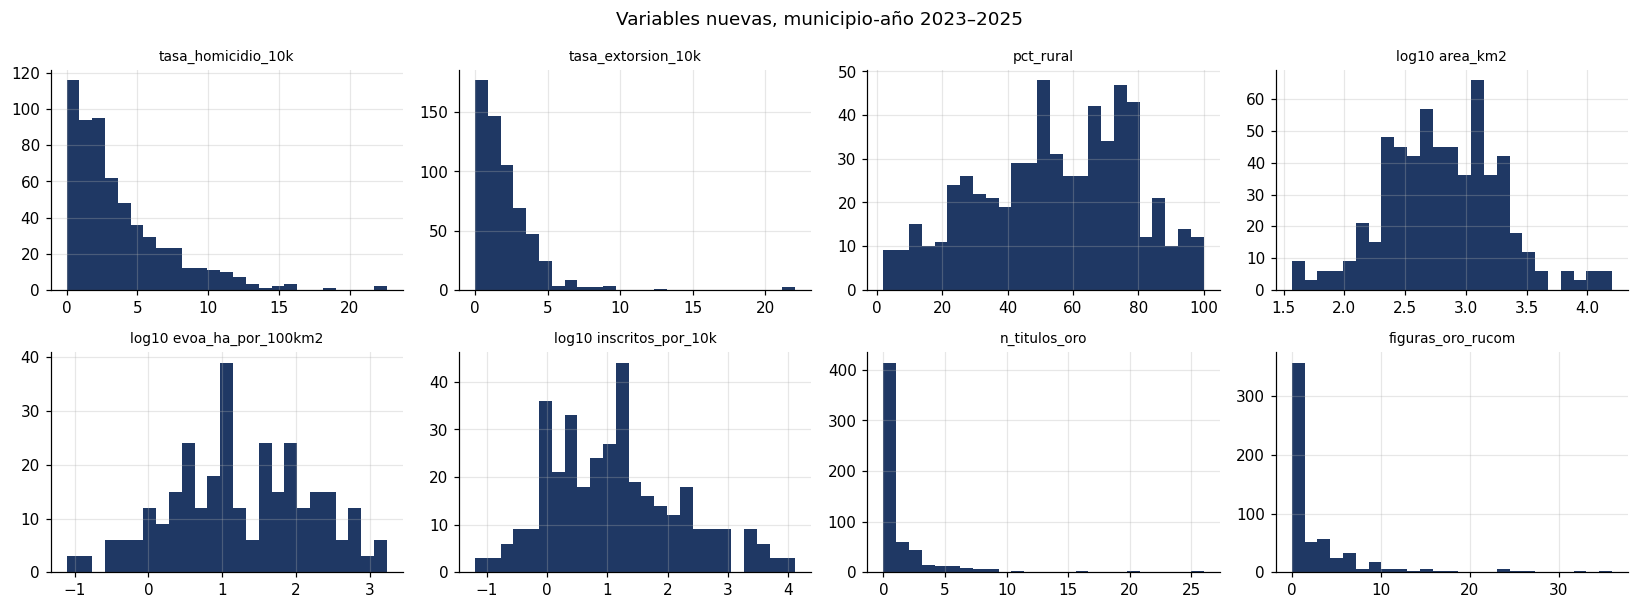

Tasas de homicidio más altas (municipio-año):


,codigo_dane,municipio,anio,homicidios,poblacion_total,tasa_homicidio_10k,tipo_predominante
35,05107,Briceño - Antioquia,2025,18,"7,957.00",22.62,aluvión con barequeo
14,05040,Anori,2025,46,"21,035.00",21.87,aluvión con títulos
161,05893,Yondo,2025,41,"22,061.00",18.59,huella sin declaración
136,05854,Valdivia,2024,24,"14,927.00",16.08,huella sin declaración
13,05040,Anori,2024,32,"20,688.00",15.47,aluvión con títulos
106,05604,Remedios,2024,50,"32,457.00",15.40,aluvión con títulos


Tasas de extorsión más altas:


,codigo_dane,municipio,anio,extorsiones,poblacion_total,tasa_extorsion_10k,tipo_predominante
343,27001,Quibdo,2024,309,"140,076.00",22.06,aluvión con barequeo
342,27001,Quibdo,2023,301,"138,336.00",21.76,aluvión con barequeo
344,27001,Quibdo,2025,187,"141,778.00",13.19,aluvión con barequeo
441,50330,Mesetas,2023,11,"11,721.00",9.38,aluvión con barequeo
442,50330,Mesetas,2024,11,"11,781.00",9.34,aluvión con barequeo
92,05425,Maceo,2025,8,"8,873.00",9.02,otros



Medianas por tipo predominante:


,municipios,tasa_homicidio,tasa_extorsion,pct_rural,huella_por_100km2,titulos_rucom,pdet
tipo_predominante,,,,,,,
aluvión con barequeo,96,2.42,1.53,57.54,0.00,0.00,0.29
aluvión con títulos,12,5.06,1.41,52.46,109.69,6.00,0.67
huella sin declaración,31,3.89,1.33,52.82,5.08,0.00,0.68
otros,17,2.52,2.37,66.67,3.75,1.00,0.24
registro sin volumen ni huella,6,2.33,1.21,48.49,0.00,0.00,0.00
veta / títulos,35,2.21,1.93,54.03,0.00,2.00,0.14


In [9]:
cols_desc = ["tasa_homicidio_10k", "tasa_extorsion_10k", "pct_rural", "area_km2", "evoa_ha_por_100km2", "minas_por_100km2", "inscritos_por_10k", "n_titulos_oro", "n_solicitudes_oro", "n_subcontratos_oro"]
desc = tabla_resumen(amp, cols_desc); display(desc)
fig, axes = plt.subplots(2, 4, figsize=(15, 5.6))
for ax, c in zip(axes.ravel(), ["tasa_homicidio_10k", "tasa_extorsion_10k", "pct_rural", "area_km2", "evoa_ha_por_100km2", "inscritos_por_10k", "n_titulos_oro", "figuras_oro_rucom"]):
    s = amp[c]; s = np.log10(s[s > 0]) if c in ("area_km2", "evoa_ha_por_100km2", "inscritos_por_10k") else s
    ax.hist(s.dropna(), bins=25, color=AZUL); ax.set_title(("log10 " if c in ("area_km2", "evoa_ha_por_100km2", "inscritos_por_10k") else "") + c, fontsize=9)
plt.suptitle("Variables nuevas, municipio-año 2023–2025"); plt.tight_layout(); plt.show()
print("Tasas de homicidio más altas (municipio-año):"); display(amp.nlargest(6, "tasa_homicidio_10k")[["codigo_dane", "municipio", "anio", "homicidios", "poblacion_total", "tasa_homicidio_10k", "tipo_predominante"]])
print("Tasas de extorsión más altas:"); display(amp.nlargest(6, "tasa_extorsion_10k")[["codigo_dane", "municipio", "anio", "extorsiones", "poblacion_total", "tasa_extorsion_10k", "tipo_predominante"]])
print("\nMedianas por tipo predominante:")
display(amp.groupby("tipo_predominante").agg(municipios=("codigo_dane", "nunique"), tasa_homicidio=("tasa_homicidio_10k", "median"), tasa_extorsion=("tasa_extorsion_10k", "median"), pct_rural=("pct_rural", "median"),
                                              huella_por_100km2=("evoa_ha_por_100km2", "median"), titulos_rucom=("n_titulos_oro", "median"), pdet=("pdet", "mean")).round(2))

### 7.2 Correlaciones con las variables del panel

Spearman, como en el notebook 01. Interesa ver si las variables nuevas aportan información distinta de la que ya había (operativos, huella, barequeo) o repiten.

Correlación de las variables nuevas con las del panel (Spearman):


,gramos_anm,g_titulos,g_barequeros,share_barequeo,ratio_tope_bareq,evoa_ha_2023,share_ilicita_2023,minas,capturas,maquinaria
tasa_homicidio_10k,0.07,0.15,0.00,-0.13,0.04,0.21,-0.05,0.05,0.06,0.17
tasa_extorsion_10k,0.06,0.14,-0.03,-0.16,-0.05,-0.09,-0.05,0.15,0.13,0.13
pct_rural,0.05,-0.04,-0.01,-0.01,-0.05,0.09,-0.01,-0.30,-0.19,-0.18
evoa_ha_por_100km2,0.33,0.18,0.36,0.04,0.35,0.99,-0.50,0.04,-0.05,0.33
inscritos_por_10k,0.44,0.23,0.46,0.14,0.31,0.36,-0.32,0.12,0.05,0.20
n_titulos_oro,0.47,0.66,0.10,-0.53,0.10,0.20,-0.49,0.11,0.15,0.05
n_solicitudes_oro,0.46,0.33,0.31,-0.16,0.34,0.47,-0.34,0.05,-0.06,0.19
n_subcontratos_oro,0.42,0.45,0.22,-0.23,0.19,0.27,-0.44,0.31,0.23,0.24
pdet,0.04,0.02,0.07,0.04,0.06,0.51,-0.07,-0.10,0.02,0.10


Entre las nuevas:


,tasa_homicidio_10k,tasa_extorsion_10k,pct_rural,evoa_ha_por_100km2,inscritos_por_10k,n_titulos_oro,n_solicitudes_oro,n_subcontratos_oro,pdet
tasa_homicidio_10k,1.00,0.23,-0.13,0.21,0.07,0.14,0.14,0.16,0.24
tasa_extorsion_10k,0.23,1.00,-0.39,-0.09,0.04,0.11,-0.01,0.02,-0.08
pct_rural,-0.13,-0.39,1.00,0.08,0.07,-0.05,0.14,-0.10,0.05
evoa_ha_por_100km2,0.21,-0.09,0.08,1.00,0.39,0.22,0.47,0.27,0.46
inscritos_por_10k,0.07,0.04,0.07,0.39,1.00,0.23,0.28,0.14,0.13
n_titulos_oro,0.14,0.11,-0.05,0.22,0.23,1.00,0.33,0.46,0.06
n_solicitudes_oro,0.14,-0.01,0.14,0.47,0.28,0.33,1.00,0.30,0.17
n_subcontratos_oro,0.16,0.02,-0.10,0.27,0.14,0.46,0.30,1.00,0.09
pdet,0.24,-0.08,0.05,0.46,0.13,0.06,0.17,0.09,1.00


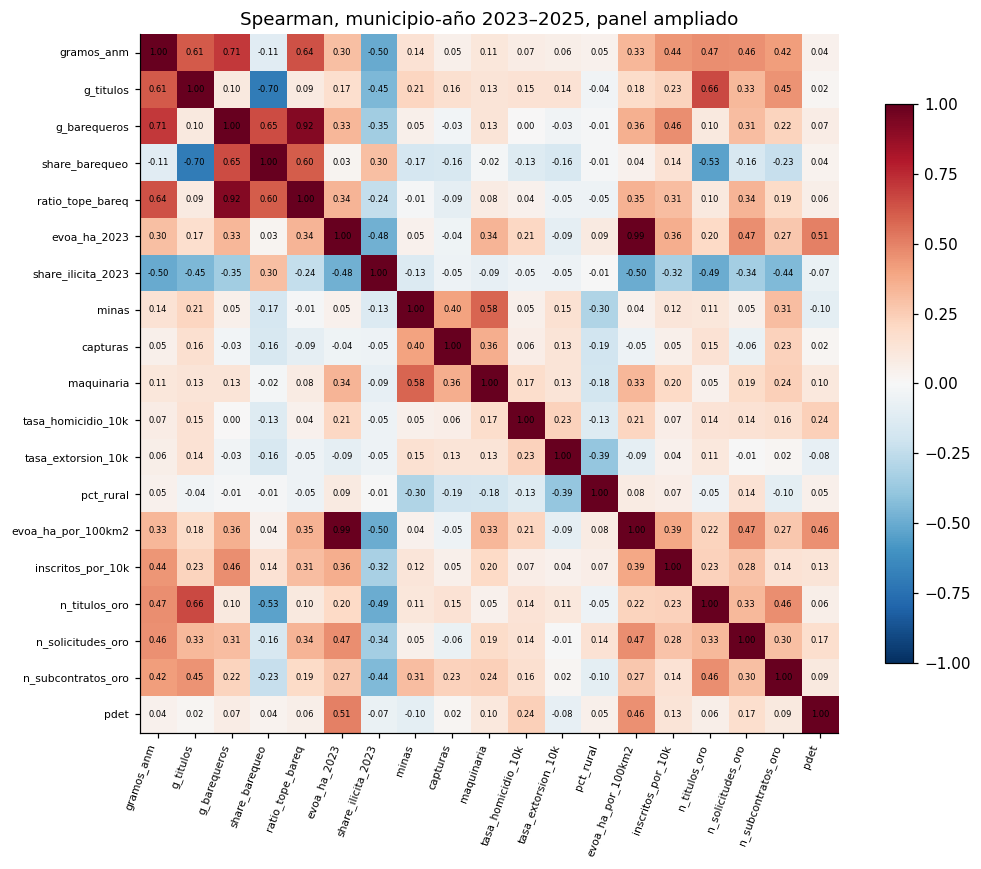

In [10]:
cc = ["gramos_anm", "g_titulos", "g_barequeros", "share_barequeo", "ratio_tope_bareq", "evoa_ha_2023", "share_ilicita_2023", "minas", "capturas", "maquinaria",
      "tasa_homicidio_10k", "tasa_extorsion_10k", "pct_rural", "evoa_ha_por_100km2", "inscritos_por_10k", "n_titulos_oro", "n_solicitudes_oro", "n_subcontratos_oro", "pdet"]
corr = amp[cc].corr(method="spearman")
print("Correlación de las variables nuevas con las del panel (Spearman):"); display(corr.loc[cc[10:], cc[:10]].round(2))
print("Entre las nuevas:"); display(corr.loc[cc[10:], cc[10:]].round(2))
fig, ax = plt.subplots(figsize=(10, 8)); im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(len(cc))); ax.set_xticklabels(cc, rotation=70, ha="right", fontsize=7); ax.set_yticks(range(len(cc))); ax.set_yticklabels(cc, fontsize=7)
for i in range(len(cc)):
    for j in range(len(cc)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=5.5)
plt.colorbar(im, ax=ax, shrink=0.8); ax.set_title("Spearman, municipio-año 2023–2025, panel ampliado"); plt.tight_layout(); plt.show()

### 7.3 Categorías nuevas para el ACM y archivos de salida

Se añaden a la tabla de categorías del notebook 01 cuatro variables: tasa de homicidio y de extorsión en terciles del universo, PDET (sí/no) y figuras de oro autorizadas en el RUCOM (ninguna / 1 a 3 / más de 3). Se vuelve a comprobar que ninguna categoría quede por debajo del 5 % de los municipios.

In [11]:
cat = pd.read_csv(SAL / "acm_categorias_municipio_2023_2025.csv", dtype={"codigo_dane": str})
m = amp.groupby("codigo_dane").agg(homic=("tasa_homicidio_10k", "mean"), extor=("tasa_extorsion_10k", "mean"), pdet=("pdet", "first"), figuras=("figuras_oro_rucom", "first")).reset_index()
def terciles(s, etiquetas):
    q = s.quantile([1/3, 2/3]).values
    return np.where(s <= q[0], etiquetas[0], np.where(s <= q[1], etiquetas[1], etiquetas[2]))
m["tasa_homicidio"] = terciles(m.homic, ["baja", "media", "alta"]); m["tasa_extorsion"] = terciles(m.extor, ["baja", "media", "alta"])
m["pdet_cat"] = np.where(m.pdet == 1, "PDET", "no PDET"); m["figuras_rucom"] = pd.cut(m.figuras, [-1, 0, 3, np.inf], labels=["ninguna", "1 a 3", "más de 3"]).astype(str)
cat2 = cat.merge(m[["codigo_dane", "tasa_homicidio", "tasa_extorsion", "pdet_cat", "figuras_rucom"]], on="codigo_dane", how="left")
VARS2 = ["tasa_homicidio", "tasa_extorsion", "pdet_cat", "figuras_rucom"]
frec = pd.concat([cat2[v].value_counts().rename_axis("categoria").reset_index(name="municipios").assign(variable=v) for v in VARS2]); frec["pct"] = (frec.municipios / len(cat2) * 100).round(1)
display(frec[["variable", "categoria", "municipios", "pct"]].reset_index(drop=True))
raras = frec[frec.pct < 5]
check("ACM", "Ninguna categoría nueva por debajo del 5 % de los municipios", len(raras) == 0, f"{len(raras)} raras: {raras[['variable', 'categoria', 'municipios']].values.tolist()}")
print("Tipo predominante × tasa de homicidio (terciles):"); display(pd.crosstab(cat2.explotador, cat2.tasa_homicidio))

# Diccionario de las variables nuevas y archivos de salida
DICC2 = pd.DataFrame([
    ("poblacion_total", "denominador", "DANE PPED 2018–2042", "población proyectada del año", "—"), ("pct_rural", "estructurales", "DANE", "población en centros poblados y rural disperso / total × 100", "—"),
    ("homicidios", "seguridad (actores armados)", "Policía m8fd-ahd9", "homicidios registrados en el año", "sin registro = 0"), ("tasa_homicidio_10k", "seguridad (actores armados)", "derivada", "homicidios / población × 10.000", "—"),
    ("extorsiones", "seguridad (actores armados)", "Policía q2ib-t9am", "extorsiones registradas en el año", "sin registro = 0"), ("tasa_extorsion_10k", "seguridad (actores armados)", "derivada", "extorsiones / población × 10.000", "—"),
    ("area_km2", "estructurales", "DANE MGN 2024", "área del municipio", "—"), ("evoa_ha_por_100km2", "estructurales", "derivada", "huella 2023 / área × 100", "0 sin huella"), ("minas_por_100km2", "seguridad (Estado)", "derivada", "minas intervenidas / área × 100", "0 sin eventos"),
    ("inscritos_por_10k", "institucionales", "derivada", "barequeros inscritos / población × 10.000", "0 sin inscritos"), ("n_titulos_oro", "institucionales", "ANM RUCOM 42ha-fhvj", "títulos de oro con explotador autorizado (foto ene-2025)", "0"),
    ("n_solicitudes_oro", "institucionales", "ANM RUCOM 7amp-4swy", "solicitudes de legalización de oro autorizadas", "0"), ("n_subcontratos_oro", "institucionales", "ANM RUCOM xzu3-gnau", "subcontratos de formalización de oro autorizados", "0"),
    ("n_titulos_oro_con_anotacion_2023_2025", "institucionales (control)", "ANM RMN si2v-pbq5", "títulos de oro con anotación registral en la ventana", "0"), ("figuras_oro_rucom", "institucionales", "derivada", "títulos + solicitudes + subcontratos", "0"),
    ("pdet", "estructurales (contexto)", "ART idrk-ba8y", "1 si el municipio es PDET", "0"), ("subregion_pdet", "estructurales (contexto)", "ART", "subregión PDET", "NaN si no es PDET"),
], columns=["variable", "familia", "fuente", "definicion", "regla_de_ausencia"])
amp.to_csv(SAL / "panel_municipal_2023_2025_ampliado.csv", index=False); ampq.to_csv(SAL / "panel_municipal_trimestral_2023_2025_ampliado.csv", index=False)
DICC2.to_csv(SAL / "panel_municipal_2023_2025_ampliado_diccionario_nuevas.csv", index=False); cat2.to_csv(SAL / "acm_categorias_municipio_2023_2025_ampliado.csv", index=False)
desc.to_csv(SAL / "caracterizacion_descriptivas_complementos_2023_2025.csv"); mv.to_csv(SAL / "caracterizacion_valores_perdidos_complementos_2023_2025.csv")
print("Guardado en", SAL); display(DICC2)

,variable,categoria,municipios,pct
0,tasa_homicidio,baja,66,33.50
1,tasa_homicidio,alta,66,33.50
2,tasa_homicidio,media,65,33.00
3,tasa_extorsion,alta,66,33.50
4,tasa_extorsion,baja,66,33.50
5,tasa_extorsion,media,65,33.00
6,pdet_cat,no PDET,131,66.50
7,pdet_cat,PDET,66,33.50
8,figuras_rucom,ninguna,75,38.10
9,figuras_rucom,1 a 3,70,35.50


[OK     ] Ninguna categoría nueva por debajo del 5 % de los municipios — 0 raras: []
Tipo predominante × tasa de homicidio (terciles):


tasa_homicidio,alta,baja,media
explotador,,,
barequeros,27,34,35
otros,5,5,7
sin declaración,18,10,9
títulos,16,17,14


Guardado en /Users/juandavidnietodallos/Documents/7 Semestre /Tesis /BDATOS-ORO/06_panel


,variable,familia,fuente,definicion,regla_de_ausencia
0,poblacion_total,denominador,DANE PPED 2018–2042,población proyectada del año,—
1,pct_rural,estructurales,DANE,población en centros poblados y rural disperso / total × 100,—
2,homicidios,seguridad (actores armados),Policía m8fd-ahd9,homicidios registrados en el año,sin registro = 0
3,tasa_homicidio_10k,seguridad (actores armados),derivada,homicidios / población × 10.000,—
4,extorsiones,seguridad (actores armados),Policía q2ib-t9am,extorsiones registradas en el año,sin registro = 0
5,tasa_extorsion_10k,seguridad (actores armados),derivada,extorsiones / población × 10.000,—
6,area_km2,estructurales,DANE MGN 2024,área del municipio,—
7,evoa_ha_por_100km2,estructurales,derivada,huella 2023 / área × 100,0 sin huella
8,minas_por_100km2,seguridad (Estado),derivada,minas intervenidas / área × 100,0 sin eventos
9,inscritos_por_10k,institucionales,derivada,barequeros inscritos / población × 10.000,0 sin inscritos


## 8. Ficha resumen de las fuentes nuevas

In [12]:
FICHA = pd.DataFrame([
    ("Homicidio (Policía)", "municipio × mes", "2023–2025, 36 meses", f"{ficha['homicidio']['ventana_municipios']} municipios con casos; total fuente reproducido", "tasa por 10.000; presencia armada"),
    ("Extorsión (Policía)", "municipio × mes", "2023–2025, 36 meses", f"{ficha['extorsion']['ventana_municipios']} municipios con casos; total fuente reproducido", "tasa por 10.000; presencia armada"),
    ("Población (DANE)", "municipio × año", "2023–2025", f"{ficha['poblacion']['municipios']} municipios; cabecera + rural = total", "denominador; % rural"),
    ("Figuras RUCOM de oro (ANM)", "municipio (foto ene-2025)", "fija", f"títulos {ficha['rucom_figuras']['titulos']['expedientes_oro']}, solicitudes {ficha['rucom_figuras']['solicitudes']['expedientes_oro']}, subcontratos {ficha['rucom_figuras']['subcontratos']['expedientes_oro']}", "conteos por municipio (institucionales)"),
    ("Anotaciones RMN (ANM)", "anotación", "2023–2025", f"{ficha['rucom_figuras']['anotaciones']['filas_ventana']:,} anotaciones; {ficha['rucom_figuras']['anotaciones']['titulos_oro_rucom_con_anotacion_2023_2025']} de {ficha['rucom_figuras']['titulos']['expedientes_oro']} títulos de oro con movimiento", "control de vigencia"),
    ("Área (DANE MGN 2024)", "municipio", "fija", f"{ficha['mgn']['municipios']} municipios, {ficha['mgn']['area_total_km2']:,} km²", "densidades por km²"),
    ("PDET (ART)", "municipio", "fija", f"{ficha['pdet']['municipios']} municipios", "categoría de contexto"),
    ("Precio base regalías (UPME)", "nacional × mes", "mar–dic 2025", f"{ficha['precios_base_upme']['meses_en_ventana']} meses; ≈ 80 % del internacional", "control de la tasa implícita"),
], columns=["fuente", "grano", "ventana", "estado", "uso en el panel"])
display(FICHA)

,fuente,grano,ventana,estado,uso en el panel
0,Homicidio (Policía),municipio × mes,"2023–2025, 36 meses",974 municipios con casos; total fuente reproducido,tasa por 10.000; presencia armada
1,Extorsión (Policía),municipio × mes,"2023–2025, 36 meses",974 municipios con casos; total fuente reproducido,tasa por 10.000; presencia armada
2,Población (DANE),municipio × año,2023–2025,1123 municipios; cabecera + rural = total,denominador; % rural
3,Figuras RUCOM de oro (ANM),municipio (foto ene-2025),fija,"títulos 268, solicitudes 112, subcontratos 174",conteos por municipio (institucionales)
4,Anotaciones RMN (ANM),anotación,2023–2025,"12,988 anotaciones; 267 de 268 títulos de oro con movimiento",control de vigencia
5,Área (DANE MGN 2024),municipio,fija,"1121 municipios, 1,140,974 km²",densidades por km²
6,PDET (ART),municipio,fija,170 municipios,categoría de contexto
7,Precio base regalías (UPME),nacional × mes,mar–dic 2025,10 meses; ≈ 80 % del internacional,control de la tasa implícita


## 9. Tabla de validaciones

In [13]:
tabla_checks = pd.DataFrame(CHECKS, columns=["bloque", "verificacion", "resultado", "detalle"]); tabla_checks.to_csv(SAL / "caracterizacion_validaciones_complementos_2023_2025.csv", index=False)
print(tabla_checks.resultado.value_counts().to_dict()); display(tabla_checks)

{'OK': 27, 'REVISAR': 3}


,bloque,verificacion,resultado,detalle
0,Inventario,Todas las fuentes nuevas están en el repositorio,OK,0 faltantes
1,05 Delictiva,homicidio: código DANE de 5 dígitos con departamento válido,OK,
2,05 Delictiva,homicidio: sin duplicados municipio-año-mes; casos enteros no negativos,OK,
3,05 Delictiva,homicidio: los tres años traen 12 meses,OK,"{2023: 12, 2024: 12, 2025: 12}"
4,05 Delictiva,homicidio: la descarga completa reproduce el total de la fuente (ficha),OK,"344,919 casos en la fuente"
5,05 Delictiva,homicidio: un solo nombre de municipio por código,OK,
6,05 Delictiva,extorsion: código DANE de 5 dígitos con departamento válido,OK,
7,05 Delictiva,extorsion: sin duplicados municipio-año-mes; casos enteros no negativos,OK,
8,05 Delictiva,extorsion: los tres años traen 12 meses,OK,"{2023: 12, 2024: 12, 2025: 12}"
9,05 Delictiva,extorsion: la descarga completa reproduce el total de la fuente (ficha),OK,"131,206 casos en la fuente"


## 10. Síntesis: qué aportan las fuentes nuevas y qué hay que decidir

### Lo que está bien

Las ocho fuentes nuevas existen, se leen sin pérdida y cruzan con el panel por el código DANE. Homicidio y extorsión traen los 36 meses de la ventana y la descarga completa reproduce el total de la fuente (344.919 y 131.206 casos). La población del DANE cubre los 197 municipios del panel en los tres años y cabecera más rural da el total en todas las filas. El área del MGN suma 1.140.974 km², el valor oficial del país con una diferencia menor del 0,1 %.

Las figuras del RUCOM se validan contra el panel: de los 80 municipios que declaran gramos por títulos, 71 (89 %) tienen al menos un título de oro autorizado en el RUCOM, y el número de títulos autorizados se correlaciona 0,66 con los gramos declarados por títulos. Las anotaciones del Registro Minero Nacional muestran que 267 de los 268 títulos de oro tuvieron movimiento registral en 2023–2025: la foto de enero de 2025 está viva dentro de la ventana.

El precio base de la UPME confirma la regla del 80 % cuando se compara con el precio internacional del mes anterior, que es como lo liquida la UPME, y con él la tasa mediana de regalía de 2025 queda en 3,9 %, es decir, el 4 % legal. Segovia, Anorí, Copacabana y Bello siguen por debajo del 2 % con el precio real: no era un problema del precio de referencia, es un régimen de liquidación distinto.

### Lo que hay que tener presente

El padrón de barequeros no es un padrón de residentes. Unión Panamericana tiene 130 inscritos por cada 100 habitantes, Lloró 78 y Caucasia 31. El documento ya advertía que el municipio de inscripción puede no ser el de venta; esto lo confirma con números y obliga a leer `n_barequeros` como capacidad de declaración, no como población minera del municipio.

Belén de Bajirá (27493) no existe como municipio en el MGN 2024, así que no tiene área ni densidades; es un solo municipio de los 197 y queda documentado. Dos nombres del MGN difieren del panel por variantes (San Andrés de Sotavento, San Sebastián de Mariquita); el código manda.

Homicidio y extorsión casi no se correlacionan con la producción declarada (0,07 y 0,06) ni con el barequeo, y la tasa de homicidio se asocia algo con la huella (0,21). Eso no las descalifica: miden otra cosa, y es justo lo que la familia de seguridad no tenía. Lo que sí dicen es que la presencia armada no sigue a la declaración, lo que va contra una lectura simple de la hipótesis 1 y a favor de que sea un rasgo de perfil, no un predictor de gramos. La proporción rural se asocia en negativo con los operativos (−0,30): la fuerza pública interviene más donde el municipio es más urbano.

Las figuras del RUCOM aportan información distinta de los gramos: los títulos autorizados van con la declaración por títulos (0,66) y en contra del barequeo (−0,53); las solicitudes de legalización van con la huella por km² (0,47). PDET se asocia con la huella (0,51) y poco con lo demás: es contexto, no factor.


